In [1]:
# 고등교육기관에서 생성한 데이터셋을 분석하여 정규과정이 끝나는 시점에서의 결과
# (dropout, enrolled, and graduate)의 다중분류예측을 위하여 3가지 이상 다중분류모델을
# 사용하고 parameter 최적화를 통해 최적의 분석모델 수립하시오. 분류성능지표(accuracy,
# f1 score, ROC-AUC 등)를 산출하고 insight를 도출할 수 있도록 시각화 하시오.
# ◼ Dataset:
# https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+suc
#  cess
# ◼ Train/Test dataset 분할비율은 default 사용(80%-20%)
# ◼ Class들의 균등분포를 위하여 stratify 옵션 사용
# ◼ sklearn.model_selection.train_test_split( ) 함수내 random_state는  100으로 설정

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
# 데이터 불러오기
df = pd.read_csv('data.csv', sep=';')

# 데이터 정보 및 결측치 확인
# print(df.info())
# print(df.isnull().sum())

In [3]:
# 타겟 분포 확인 및 라벨 인코딩
# print(df['Target'].value_counts())
label_encoder = LabelEncoder()
df['Target_encoded'] = label_encoder.fit_transform(df['Target'])
class_names = label_encoder.classes_
# print(df['Target_encoded'].value_counts())

# 피처, 타겟 분리
X = df.drop(['Target', 'Target_encoded'], axis=1)
y = df['Target_encoded']

# 학습/테스트 데이터 분할 (stratify + random_state 고정)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=100
)

In [4]:
# 표준화 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 모델과 하이퍼파라미터 튜닝
models = {
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss'),
    'SVM': SVC(probability=True)  # ROC-AUC 위해 probability=True 필요
}

params = {
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5, 10],
        'reg_alpha': [0, 0.1],
        'reg_lambda': [1, 10]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
    }
}



================ RandomForest =================
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.7909604519774012
F1 Score (weighted): 0.7773226625192454

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.75      0.80       284
           1       0.67      0.41      0.51       159
           2       0.79      0.95      0.86       442

    accuracy                           0.79       885
   macro avg       0.77      0.70      0.72       885
weighted avg       0.79      0.79      0.78       885

ROC AUC (weighted, OvR): 0.9092465875107015


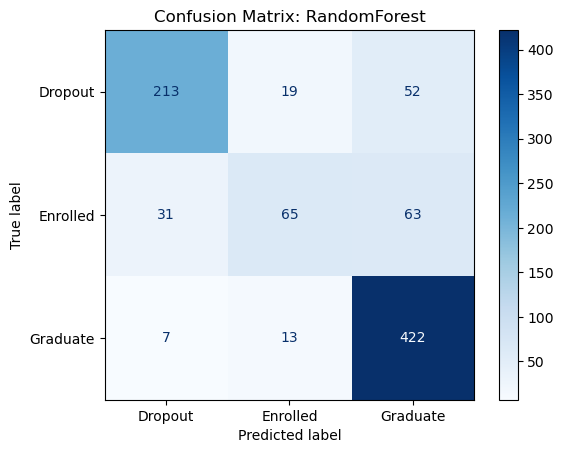

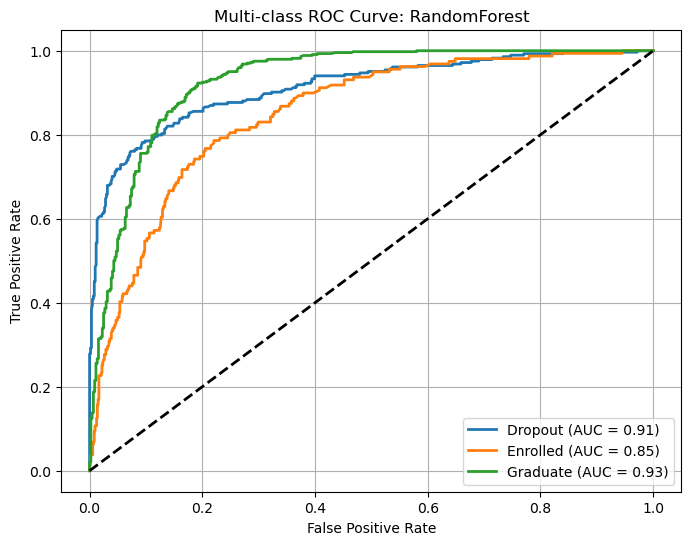


================ XGBoost =================
Best Parameters: {'max_depth': 5, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 1}
Accuracy: 0.7751412429378531
F1 Score (weighted): 0.7648346988268949

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.74      0.79       284
           1       0.55      0.41      0.47       159
           2       0.80      0.93      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.77      0.78      0.76       885

ROC AUC (weighted, OvR): 0.9098533942436896


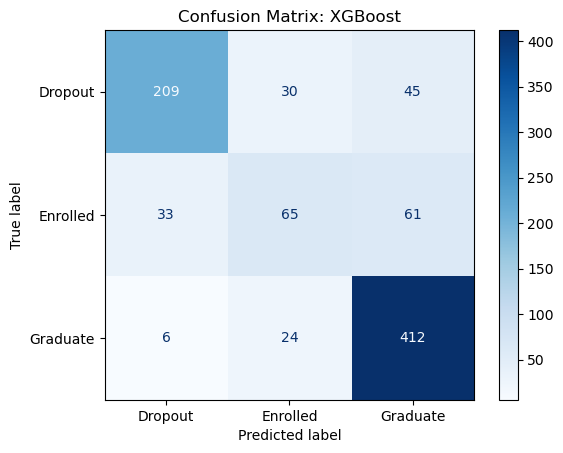

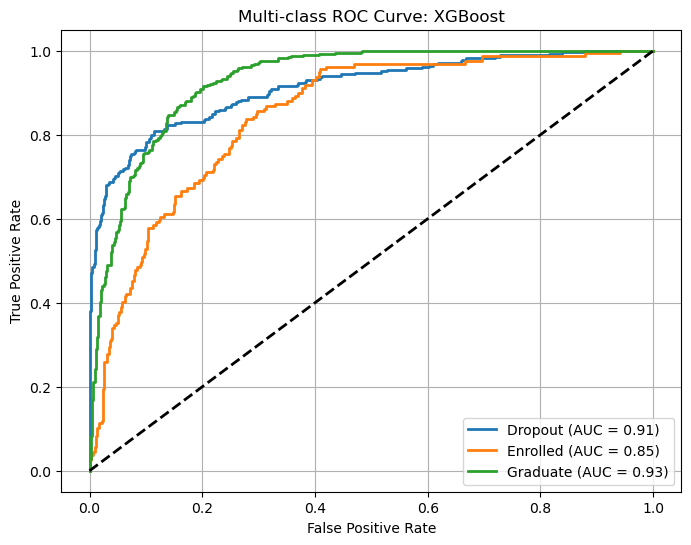


================ SVM =================
Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy: 0.7774011299435029
F1 Score (weighted): 0.7648946109389804

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.71      0.78       284
           1       0.60      0.41      0.49       159
           2       0.77      0.95      0.85       442

    accuracy                           0.78       885
   macro avg       0.75      0.69      0.71       885
weighted avg       0.77      0.78      0.76       885

ROC AUC (weighted, OvR): 0.9023768295860063


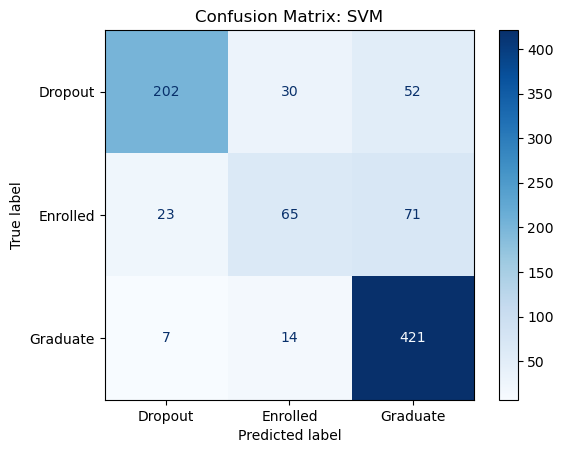

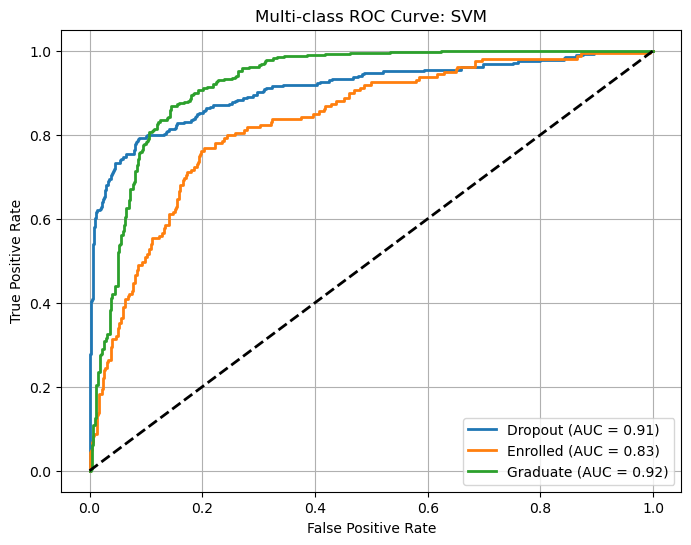

In [6]:
# 결과 저장용 리스트
results = []

# 반복문으로 세 모델에 대해 처리
for model_name, model_obj in models.items():
    print(f"\n================ {model_name} =================")
    
    if params[model_name]:
        grid_search = GridSearchCV(
            estimator=model_obj,
            param_grid=params[model_name],
            scoring='f1_weighted',
            cv=5,
            n_jobs=-1,
        )
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        print("Best Parameters:", grid_search.best_params_)
    else:
        best_model = model_obj
        best_model.fit(X_train_scaled, y_train)

    # 예측
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)

    # 평가 지표 출력
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("Accuracy:", acc)
    print("F1 Score (weighted):", f1)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # ROC-AUC 계산
    y_test_bin = label_binarize(y_test, classes=best_model.classes_)
    roc_auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')
    print("ROC AUC (weighted, OvR):", roc_auc)

    # 결과 저장
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })

    # 혼동행렬 시각화
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    # ROC Curve 시각화
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_label} (AUC = {roc_auc_i:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-class ROC Curve: {model_name}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

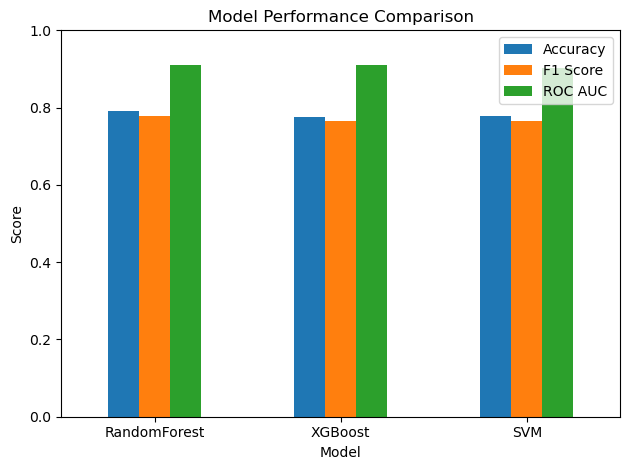

In [7]:
# 성능 비교 표 출력
results_df = pd.DataFrame(results)
results_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC AUC']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()